# Attention Is All You Need — Paper Review, Full Transformer Implementation, and Project Notebook

This notebook is our structured learning guide for the 2017 paper **“Attention Is All You Need”** by Vaswani et al. It moves from research paper review to PyTorch implementation, then to custom object-oriented implementation, and finally to a complete text-classification project using a scikit-learn dataset.

Our learning goals:

1. Understand why the Transformer was proposed.
2. Review every major idea in the paper: self-attention, multi-head attention, positional encoding, encoder, decoder, masking, residual connections, layer normalization, feed-forward networks, label smoothing, Noam learning-rate schedule, training setup, results, gaps, and future directions.
3. Use PyTorch built-in Transformer components first.
4. Build the Transformer manually using Python OOP and PyTorch.
5. Complete an end-to-end project using the `fetch_20newsgroups` dataset from scikit-learn.

> Style note: This notebook uses **we** and **our** as learning language.

## Notebook Roadmap

| Section | Purpose |
|---|---|
| 1. Paper context | Why the Transformer was needed |
| 2. Paper review | Main claims, architecture, equations, experiments |
| 3. Built-in PyTorch implementation | Use `nn.MultiheadAttention`, `nn.TransformerEncoderLayer`, `nn.Transformer`, and masks |
| 4. Custom OOP implementation | Build attention, encoder, decoder, encoder-decoder Transformer |
| 5. Training utilities | Label smoothing, Noam scheduler, batching, masks |
| 6. Project | Text classification with scikit-learn 20 Newsgroups dataset |
| 7. Interview notes | Common questions and strong answer points |
| 8. Gaps and future work | Limitations of the original paper and later research directions |

## Paper Metadata

| Item | Detail |
|---|---|
| Paper | **Attention Is All You Need** |
| Authors | Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin |
| First version | 2017 |
| Main architecture | Transformer |
| Main claim | Sequence transduction can be solved using attention without recurrence or convolution |
| Core tasks | Machine translation: WMT 2014 English-German and English-French |
| Major result | Higher BLEU and better parallelization than earlier recurrent/convolutional seq2seq systems |

The paper replaced recurrence-based sequence modeling with **self-attention**, allowing all tokens in a sequence to interact directly in parallel.

## Before the Transformer: Why the Paper Was Important

Before this paper, many strong sequence-to-sequence models used RNNs, LSTMs, GRUs, or CNNs. These models had important weaknesses:

### RNN/LSTM/GRU limitation

RNN-style models process tokens sequentially. Token `t` depends on previous hidden states, so training cannot fully parallelize across the sequence length. Long-range dependencies are also difficult because information must pass through many recurrent steps.

### CNN limitation

CNN sequence models parallelize better than RNNs, but connecting distant tokens requires many layers or wide kernels. CNNs also use local receptive fields unless depth is increased.

### Earlier attention limitation

Earlier attention was often added on top of an RNN encoder-decoder. The attention helped the decoder focus on encoder states, but recurrence still remained the backbone.

### Transformer solution

The paper proposed: **remove recurrence and convolution completely, and use attention as the main computation.**

## Core Contributions of the Paper

The paper contributed several ideas as a combined architecture:

1. **Scaled dot-product attention**: efficient attention using query, key, and value vectors.
2. **Multi-head attention**: several attention heads learn different relational patterns.
3. **Self-attention encoder**: every source token attends to every source token.
4. **Masked self-attention decoder**: each target token can attend only to earlier target tokens.
5. **Cross-attention**: decoder attends to encoder outputs.
6. **Sinusoidal positional encoding**: order information is added without recurrence.
7. **Residual connections and layer normalization**: stable deep training.
8. **Position-wise feed-forward network**: non-linear transformation applied independently at each position.
9. **Parallelizable sequence modeling**: all tokens in a layer can be processed together.
10. **Strong translation results with less training time** compared with earlier systems.

## Transformer Architecture at a High Level

The original Transformer is an **encoder-decoder** architecture.

### Encoder

The encoder receives the source sentence and produces contextual token representations. It is made of `N = 6` identical layers in the paper.

Each encoder layer has:

1. Multi-head self-attention
2. Add & Norm
3. Position-wise feed-forward network
4. Add & Norm

### Decoder

The decoder generates the target sentence one token at a time. It is also made of `N = 6` identical layers.

Each decoder layer has:

1. Masked multi-head self-attention
2. Add & Norm
3. Encoder-decoder cross-attention
4. Add & Norm
5. Position-wise feed-forward network
6. Add & Norm

### Why masking matters

During training, target tokens are known, but the decoder must not see future tokens. A causal mask hides future positions so the model learns real auto-regressive generation.

## Scaled Dot-Product Attention

Attention uses three matrices:

- **Query (Q)**: what a token is looking for
- **Key (K)**: what each token offers for matching
- **Value (V)**: information returned after attention weights are computed

The paper defines scaled dot-product attention as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

### Why divide by $\sqrt{d_k}$?

When the key/query dimension is large, raw dot products can have high variance. Large values push softmax into saturated regions, causing small gradients. Scaling by $\sqrt{d_k}$ keeps scores numerically stable.

### Interview answer

Scaled dot-product attention computes similarity between queries and keys, converts similarities into a probability distribution with softmax, and uses that distribution to mix values. The scaling term prevents extremely large dot products and improves training stability.

## Multi-Head Attention

Instead of performing attention once, the Transformer performs attention multiple times in parallel.

For each head:

$$
head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
$$

Then heads are concatenated:

$$
MultiHead(Q,K,V) = Concat(head_1, ..., head_h)W^O
$$

### Why multiple heads?

Different heads can focus on different relationships:

- Nearby word relations
- Long-range dependencies
- Syntax-like patterns
- Entity relationships
- Positional patterns
- Task-specific semantic links

### Paper configuration

The base model used:

- `d_model = 512`
- `h = 8` heads
- `d_k = d_v = 64`

### Interview answer

Multi-head attention improves representation capacity because each head learns attention in a different projected subspace. Instead of one attention map, the model learns several relation maps and combines them.

## Positional Encoding

Self-attention does not naturally understand token order because attention treats input tokens as a set unless order information is added.

The paper adds positional encoding to token embeddings:

$$
PE_{(pos, 2i)} = \sin\left(pos / 10000^{2i/d_{model}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos\left(pos / 10000^{2i/d_{model}}\right)
$$

### Why sinusoidal encoding?

Sinusoidal encoding gives each position a unique pattern. It can also help the model learn relative position relationships because shifted positions have predictable sinusoidal relationships.

### Learned vs sinusoidal positional encoding

The paper reported similar performance between learned and sinusoidal positional encodings. Sinusoidal encoding has the advantage of extrapolation to longer sequence lengths than those seen during training.

## Position-Wise Feed-Forward Network

Each encoder and decoder block contains a feed-forward network applied independently to each position:

$$
FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
$$

In the base Transformer:

- `d_model = 512`
- hidden dimension `d_ff = 2048`
- activation: ReLU in the paper

### Why feed-forward after attention?

Attention mixes information across positions. The feed-forward network then transforms each token representation non-linearly. This creates depth and capacity.

## Residual Connection and Layer Normalization

Every sub-layer is wrapped with residual connection and layer normalization:

$$
LayerNorm(x + Sublayer(x))
$$

The paper uses the post-normalization style above. Many modern Transformers often use pre-normalization:

$$
x + Sublayer(LayerNorm(x))
$$

### Why residual connections?

Residual connections improve gradient flow and allow deeper networks to train.

### Why layer normalization?

Layer normalization stabilizes activations across feature dimensions and improves optimization.

## Decoder Masking

The decoder uses masked self-attention so token position `t` cannot attend to target positions greater than `t`.

For example, with 5 target tokens, the causal mask is:

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 & 0 \\
1 & 1 & 1 & 0 & 0 \\
1 & 1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1 & 1
\end{bmatrix}
$$

This mask preserves auto-regressive learning.

## Complexity Comparison from the Paper

For sequence length `n`, representation dimension `d`, and convolution kernel size `k`:

| Layer type | Complexity per layer | Sequential operations | Maximum path length |
|---|---:|---:|---:|
| Self-attention | $O(n^2d)$ | $O(1)$ | $O(1)$ |
| Recurrent | $O(nd^2)$ | $O(n)$ | $O(n)$ |
| Convolutional | $O(knd^2)$ | $O(1)$ | $O(log_k(n))$ or $O(n/k)$ depending on design |

### Meaning

Self-attention gives a short path between any two tokens. A token can directly attend to any other token in one layer. This is very powerful for long-range dependencies, though the $O(n^2)$ cost becomes expensive for long sequences.

## Paper Training Setup

The paper used:

- Optimizer: Adam
- Betas: $\beta_1 = 0.9$, $\beta_2 = 0.98$
- Epsilon: $10^{-9}$
- Learning-rate schedule with warmup:

$$
lrate = d_{model}^{-0.5} \cdot min(step^{-0.5}, step \cdot warmup^{-1.5})
$$

- Warmup steps: 4000
- Dropout: 0.1
- Label smoothing: 0.1
- Base model: `N=6`, `d_model=512`, `d_ff=2048`, `h=8`
- Big model: larger dimension, more heads, and more parameters

### Why Noam schedule?

The schedule warms up gradually at the beginning, then decays with inverse square root. Warmup prevents early instability; decay supports convergence.

## Paper Results and Claims

The paper showed strong results on machine translation:

- WMT 2014 English-to-German: strong BLEU improvement over earlier models.
- WMT 2014 English-to-French: strong single-model BLEU with much lower training cost than previous large systems.
- The model also generalized to English constituency parsing.

### Key claim

The Transformer was not only accurate but also highly parallelizable, making it faster to train than recurrent sequence models.

## Gaps and Limitations of the Original Paper

The original paper was groundbreaking, but it had clear limitations:

### 1. Quadratic attention cost

Self-attention has $O(n^2)$ memory and compute with respect to sequence length. Long documents, videos, and high-resolution images become expensive.

### 2. Data and compute requirement

Transformers are powerful but often require large datasets and significant compute to outperform smaller baselines.

### 3. Limited interpretability

Attention maps are useful for inspection, but attention weights are not always faithful explanations.

### 4. Positional handling is simple

Sinusoidal positional encoding is elegant, but later work explored relative position encodings, rotary embeddings, ALiBi, and other improvements.

### 5. Machine translation focus

The original paper mainly focused on translation and parsing, not broad language understanding, document classification, multimodal learning, or generative pretraining.

### 6. No pretrained language model framework

The paper introduced the architecture, but did not introduce BERT/GPT-style large-scale pretraining and fine-tuning.

### 7. Exposure bias still exists in decoder generation

The model is trained with teacher forcing but generates auto-regressively during inference. This train-test mismatch can still affect generation.

### 8. No direct solution for hallucination or factuality

The architecture improves sequence modeling, but factual grounding and reliability need additional methods.

## Future Work Directions After the Paper

Important future directions inspired by the paper include:

1. **Efficient attention**: sparse attention, linear attention, sliding-window attention, memory attention.
2. **Pretraining**: BERT, GPT, T5, encoder-only, decoder-only, and encoder-decoder pretraining.
3. **Long-context modeling**: longer sequence memory and retrieval-augmented modeling.
4. **Better positional encodings**: relative position, RoPE, ALiBi.
5. **Multimodal Transformers**: vision, speech, audio, video, tabular, and cross-modal systems.
6. **Interpretability**: probing heads, mechanistic interpretability, circuit analysis.
7. **Efficiency**: quantization, distillation, pruning, low-rank adaptation, parameter-efficient fine-tuning.
8. **Safer generation**: factuality, grounding, uncertainty, alignment, controllability.
9. **Smaller domain-specific Transformers**: efficient models for low-resource settings.
10. **Hybrid models**: Transformer plus convolution, state-space models, retrieval, memory, or graph structures.

# Part A — Setup

In [1]:
import math
import random
import re
import time
from collections import Counter
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [2]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Part B — PyTorch Built-In Transformer Components

Before building our own Transformer, we first inspect how PyTorch provides official Transformer components.

Important classes:

- `nn.MultiheadAttention`
- `nn.TransformerEncoderLayer`
- `nn.TransformerDecoderLayer`
- `nn.TransformerEncoder`
- `nn.TransformerDecoder`
- `nn.Transformer`

## 16. Built-In Multi-Head Attention Demo

The following cell creates a batch of random token embeddings and passes them through PyTorch's built-in multi-head attention.

In [3]:
batch_size = 2
seq_len = 5
d_model = 32
num_heads = 4

x = torch.randn(batch_size, seq_len, d_model)

mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=num_heads,
    dropout=0.1,
    batch_first=True
)

attn_output, attn_weights = mha(query=x, key=x, value=x, need_weights=True)

print("Input shape:", x.shape)
print("Attention output shape:", attn_output.shape)
print("Attention weight shape:", attn_weights.shape)

Input shape: torch.Size([2, 5, 32])
Attention output shape: torch.Size([2, 5, 32])
Attention weight shape: torch.Size([2, 5, 5])


## 17. Built-In Encoder Layer Demo

A Transformer encoder layer contains self-attention and a feed-forward network.

In [4]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=d_model,
    nhead=num_heads,
    dim_feedforward=128,
    dropout=0.1,
    batch_first=True,
    activation="relu"
)

encoder_out = encoder_layer(x)
print("Encoder output shape:", encoder_out.shape)

Encoder output shape: torch.Size([2, 5, 32])


## 18. Built-In Full Transformer Demo

PyTorch's `nn.Transformer` provides an encoder-decoder Transformer. It expects source and target embeddings. Usually, token IDs are first converted into embeddings, then positional encodings are added.

In [5]:
src_len = 7
tgt_len = 6

src = torch.randn(batch_size, src_len, d_model)
tgt = torch.randn(batch_size, tgt_len, d_model)

transformer = nn.Transformer(
    d_model=d_model,
    nhead=num_heads,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    batch_first=True
)

causal_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len)

out = transformer(src=src, tgt=tgt, tgt_mask=causal_mask)
print("Full Transformer output shape:", out.shape)

Full Transformer output shape: torch.Size([2, 6, 32])


# Part C — Custom Transformer Implementation from Scratch with OOP

Now we implement the core solution ourselves using Python classes.

We build:

1. Token embedding + positional encoding
2. Scaled dot-product attention
3. Multi-head attention
4. Position-wise feed-forward network
5. Encoder block
6. Decoder block
7. Encoder stack
8. Decoder stack
9. Full encoder-decoder Transformer
10. Masks and training utilities

## Positional Encoding Implementation

In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from the Transformer paper."""

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

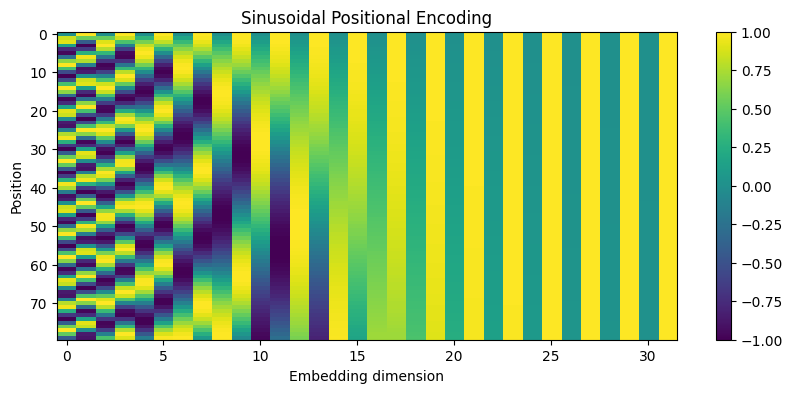

In [7]:
# Visualize the sinusoidal positional encoding matrix.
pe_demo = PositionalEncoding(d_model=32, max_len=80, dropout=0.0)
pe_matrix = pe_demo.pe.squeeze(0).numpy()

plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix, aspect="auto")
plt.colorbar()
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.show()

## Scaled Dot-Product Attention Implementation

In [8]:
def scaled_dot_product_attention(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    mask: Optional[torch.Tensor] = None,
    dropout: Optional[nn.Module] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    query, key, value shape: (batch, heads, seq_len, head_dim)
    mask shape should be broadcastable to (batch, heads, query_len, key_len)
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attn_weights = F.softmax(scores, dim=-1)

    if dropout is not None:
        attn_weights = dropout(attn_weights)

    output = torch.matmul(attn_weights, value)
    return output, attn_weights

In [9]:
# Tiny attention example.
q = torch.randn(2, 4, 5, 8)
k = torch.randn(2, 4, 5, 8)
v = torch.randn(2, 4, 5, 8)

attention_output, attention_weights = scaled_dot_product_attention(q, k, v)
print("Attention output:", attention_output.shape)
print("Attention weights:", attention_weights.shape)

Attention output: torch.Size([2, 4, 5, 8])
Attention weights: torch.Size([2, 4, 5, 5])


## Multi-Head Attention Implementation

In [10]:
class MultiHeadAttentionCustom(nn.Module):
    """Multi-head attention implemented from the Transformer paper."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, d_model = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)  # (batch, heads, seq_len, head_dim)

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, heads, seq_len, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, heads * head_dim)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        q = self._split_heads(self.q_linear(query))
        k = self._split_heads(self.k_linear(key))
        v = self._split_heads(self.v_linear(value))

        attn_output, attn_weights = scaled_dot_product_attention(
            q, k, v, mask=mask, dropout=self.dropout
        )

        combined = self._combine_heads(attn_output)
        output = self.out_linear(combined)
        return output, attn_weights

In [11]:
custom_mha = MultiHeadAttentionCustom(d_model=32, num_heads=4)
x_demo = torch.randn(2, 5, 32)
custom_out, custom_weights = custom_mha(x_demo, x_demo, x_demo)

print("Custom MHA output:", custom_out.shape)
print("Custom MHA weights:", custom_weights.shape)

Custom MHA output: torch.Size([2, 5, 32])
Custom MHA weights: torch.Size([2, 4, 5, 5])


## Position-Wise Feed-Forward Network Implementation

In [12]:
class PositionWiseFeedForward(nn.Module):
    """Position-wise FFN: Linear -> ReLU -> Dropout -> Linear."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## Encoder Block Implementation

This block follows the paper's post-norm form:

$$
LayerNorm(x + Sublayer(x))
$$

In [13]:
class TransformerEncoderBlockCustom(nn.Module):
    """One encoder block from the original Transformer."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(
        self, x: torch.Tensor, src_mask: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        attn_out, attn_weights = self.self_attn(x, x, x, mask=src_mask)
        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x, attn_weights

## Decoder Block Implementation

The decoder block contains:

1. Masked self-attention over target tokens
2. Cross-attention over encoder memory
3. Feed-forward network

In [14]:
class TransformerDecoderBlockCustom(nn.Module):
    """One decoder block from the original Transformer."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttentionCustom(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: Optional[torch.Tensor] = None,
        memory_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        self_attn_out, self_attn_weights = self.self_attn(x, x, x, mask=tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_out))

        cross_attn_out, cross_attn_weights = self.cross_attn(
            x, memory, memory, mask=memory_mask
        )
        x = self.norm2(x + self.dropout2(cross_attn_out))

        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))
        return x, self_attn_weights, cross_attn_weights

## Encoder and Decoder Stacks

In [15]:
class TransformerEncoderCustom(nn.Module):
    """Stack of Transformer encoder blocks."""

    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_layers: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.1,
        max_len: int = 5000,
        pad_id: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.pad_id = pad_id
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlockCustom(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(
        self, src_ids: torch.Tensor, src_mask: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, List[torch.Tensor]]:
        x = self.token_embedding(src_ids) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        attention_maps = []
        for layer in self.layers:
            x, attn = layer(x, src_mask)
            attention_maps.append(attn)

        return x, attention_maps


class TransformerDecoderCustom(nn.Module):
    """Stack of Transformer decoder blocks."""

    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_layers: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.1,
        max_len: int = 5000,
        pad_id: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.pad_id = pad_id
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            TransformerDecoderBlockCustom(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(
        self,
        tgt_ids: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: Optional[torch.Tensor] = None,
        memory_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, List[torch.Tensor], List[torch.Tensor]]:
        x = self.token_embedding(tgt_ids) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        self_attention_maps = []
        cross_attention_maps = []

        for layer in self.layers:
            x, self_attn, cross_attn = layer(
                x, memory, tgt_mask=tgt_mask, memory_mask=memory_mask
            )
            self_attention_maps.append(self_attn)
            cross_attention_maps.append(cross_attn)

        return x, self_attention_maps, cross_attention_maps

## Mask Utilities

In [16]:
def make_pad_mask(seq_ids: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    """
    Return mask shape (batch, 1, 1, seq_len), where 1 means valid token.
    """
    return (seq_ids != pad_id).unsqueeze(1).unsqueeze(2)


def make_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """
    Return lower-triangular causal mask shape (1, 1, seq_len, seq_len).
    """
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()
    return mask.unsqueeze(0).unsqueeze(0)


def make_tgt_mask(tgt_ids: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    pad_mask = make_pad_mask(tgt_ids, pad_id=pad_id)
    causal_mask = make_causal_mask(tgt_ids.size(1), tgt_ids.device)
    return pad_mask & causal_mask

In [17]:
mask_demo = make_causal_mask(seq_len=6, device=torch.device("cpu")).squeeze().int()
print(mask_demo)

tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


## Full Encoder-Decoder Transformer Implementation

In [18]:
class TransformerSeq2SeqCustom(nn.Module):
    """Full encoder-decoder Transformer for sequence-to-sequence tasks."""

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int = 512,
        num_layers: int = 6,
        num_heads: int = 8,
        d_ff: int = 2048,
        dropout: float = 0.1,
        max_len: int = 5000,
        pad_id: int = 0,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.encoder = TransformerEncoderCustom(
            vocab_size=src_vocab_size,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
            max_len=max_len,
            pad_id=pad_id,
        )
        self.decoder = TransformerDecoderCustom(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
            max_len=max_len,
            pad_id=pad_id,
        )
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src_ids: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
        src_mask = make_pad_mask(src_ids, pad_id=self.pad_id)
        tgt_mask = make_tgt_mask(tgt_ids, pad_id=self.pad_id)
        memory_mask = src_mask

        memory, _ = self.encoder(src_ids, src_mask=src_mask)
        decoder_out, _, _ = self.decoder(
            tgt_ids, memory, tgt_mask=tgt_mask, memory_mask=memory_mask
        )
        logits = self.output_projection(decoder_out)
        return logits

In [19]:
# Tiny forward pass test for the full custom seq2seq Transformer.
src_vocab_size = 100
tgt_vocab_size = 120
pad_id = 0

seq2seq_model = TransformerSeq2SeqCustom(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=32,
    num_layers=2,
    num_heads=4,
    d_ff=128,
    dropout=0.1,
    max_len=50,
    pad_id=pad_id,
)

src_ids = torch.randint(1, src_vocab_size, (2, 7))
tgt_ids = torch.randint(1, tgt_vocab_size, (2, 6))
logits = seq2seq_model(src_ids, tgt_ids)

print("Seq2Seq logits shape:", logits.shape)
print("Trainable parameters:", count_parameters(seq2seq_model))

Seq2Seq logits shape: torch.Size([2, 6, 120])
Trainable parameters: 70392


# Part D — Training Utilities from the Paper

The original paper used label smoothing and a custom learning-rate schedule. We implement both.

## Label Smoothing Loss

Label smoothing prevents the model from becoming overconfident. Instead of assigning probability 1.0 to the correct class and 0.0 to all others, a small amount of probability is distributed across incorrect classes.

In [20]:
class LabelSmoothingLoss(nn.Module):
    """Cross-entropy with label smoothing for token prediction."""

    def __init__(self, vocab_size: int, padding_idx: int = 0, smoothing: float = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.padding_idx = padding_idx
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # logits: (batch, seq_len, vocab_size)
        # target: (batch, seq_len)
        logits = logits.reshape(-1, self.vocab_size)
        target = target.reshape(-1)

        log_probs = F.log_softmax(logits, dim=-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
            true_dist[:, self.padding_idx] = 0
            padding_mask = target == self.padding_idx
            true_dist[padding_mask] = 0

        loss = torch.sum(-true_dist * log_probs, dim=-1)
        non_pad_count = (target != self.padding_idx).sum().clamp_min(1)
        return loss.sum() / non_pad_count

## Noam Learning Rate Scheduler

In [21]:
class NoamScheduler:
    """Learning-rate scheduler used in the Transformer paper."""

    def __init__(self, optimizer, d_model: int, warmup_steps: int = 4000, factor: float = 1.0):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor
        self.step_num = 0

    def rate(self, step: Optional[int] = None) -> float:
        if step is None:
            step = self.step_num
        step = max(step, 1)
        return self.factor * (self.d_model ** -0.5) * min(
            step ** -0.5, step * (self.warmup_steps ** -1.5)
        )

    def step(self) -> float:
        self.step_num += 1
        lr = self.rate()
        for group in self.optimizer.param_groups:
            group["lr"] = lr
        self.optimizer.step()
        return lr

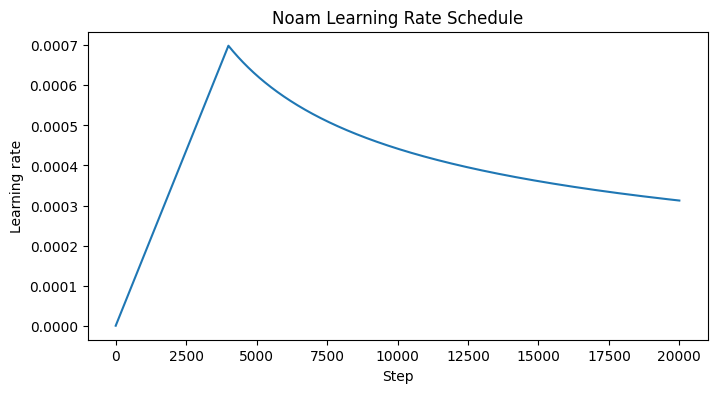

In [22]:
# Visualize Noam schedule.
d_model_for_schedule = 512
warmup = 4000
steps = np.arange(1, 20000)
rates = [
    (d_model_for_schedule ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    for step in steps
]

plt.figure(figsize=(8, 4))
plt.plot(steps, rates)
plt.title("Noam Learning Rate Schedule")
plt.xlabel("Step")
plt.ylabel("Learning rate")
plt.show()

# Part E — Project: Text Classification with a Transformer Encoder

The original paper is sequence-to-sequence focused. For a practical end-to-end project, we will use a **Transformer encoder** for document classification.

Dataset: `fetch_20newsgroups` from scikit-learn.

Why this dataset fits the project:

- It is a text dataset.
- It supports classification.
- It allows a realistic NLP pipeline: loading, cleaning, tokenization, vocabulary, padding, batching, Transformer encoder, training, evaluation, and inference.

To keep training fast, our project uses four categories.

## Load Dataset from scikit-learn

The full 20 Newsgroups dataset has 20 classes. We use four categories so the notebook runs faster in Colab.

In [23]:
CATEGORIES = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.med",
    "talk.politics.misc",
]


def load_project_dataset(categories: List[str] = CATEGORIES):
    """Load the 20 Newsgroups dataset. Fallback data keeps the notebook runnable if download is unavailable."""
    try:
        train_data = fetch_20newsgroups(
            subset="train",
            categories=categories,
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=SEED,
        )
        test_data = fetch_20newsgroups(
            subset="test",
            categories=categories,
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=SEED,
        )
        return train_data.data, train_data.target, test_data.data, test_data.target, train_data.target_names
    except Exception as error:
        print("Dataset download failed. Using a tiny fallback dataset for code demonstration.")
        print("Reason:", repr(error))
        fallback_texts = [
            "graphics rendering image pixel display color animation",
            "baseball team pitcher game season player bat score",
            "medicine doctor patient disease treatment health study",
            "government election policy parliament political debate law",
        ] * 80
        fallback_targets = np.array([0, 1, 2, 3] * 80)
        X_train, X_test, y_train, y_test = train_test_split(
            fallback_texts,
            fallback_targets,
            test_size=0.25,
            stratify=fallback_targets,
            random_state=SEED,
        )
        return X_train, y_train, X_test, y_test, categories

X_train_raw, y_train, X_test_raw, y_test, target_names = load_project_dataset()

print("Train samples:", len(X_train_raw))
print("Test samples:", len(X_test_raw))
print("Classes:", target_names)
print("Sample text:\n", X_train_raw[0][:600])

Train samples: 2240
Test samples: 1492
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.misc']
Sample text:
 
The speculum is the little cone that fits on the end of the otoscope.
There are also vaginal specula that females and gynecologists are
all too familiar with.
-- 
----------------------------------------------------------------------------
Gordon Banks  N3JXP      | "Skepticism is the chastity of the intellect, and
geb@cadre.dsl.pitt.edu   |  it is shameful to surrender it too soon." 


In [24]:
class_counts = pd.Series(y_train).value_counts().sort_index()
pd.DataFrame({"class_name": target_names, "train_count": class_counts.values})

,class_name,train_count
0,comp.graphics,584
1,rec.sport.baseball,597
2,sci.med,594
3,talk.politics.misc,465


## Text Cleaning and Tokenization

For learning purposes, we use a simple regex tokenizer. Production systems often use subword tokenizers such as BPE, WordPiece, or SentencePiece.

In [25]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z][a-zA-Z']+")


def tokenize(text: str) -> List[str]:
    text = text.lower()
    tokens = TOKEN_PATTERN.findall(text)
    return tokens

print(tokenize("Transformers use self-attention for sequence modeling!"))

['transformers', 'use', 'self', 'attention', 'for', 'sequence', 'modeling']


## Build Vocabulary

In [26]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1


def build_vocab(texts: List[str], max_vocab_size: int = 20000, min_freq: int = 2) -> Dict[str, int]:
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
    for token, freq in counter.most_common(max_vocab_size - len(vocab)):
        if freq >= min_freq:
            vocab[token] = len(vocab)
    return vocab

vocab = build_vocab(X_train_raw, max_vocab_size=12000, min_freq=2)
print("Vocabulary size:", len(vocab))
print("First 20 items:", list(vocab.items())[:20])

Vocabulary size: 12000
First 20 items: [('<pad>', 0), ('<unk>', 1), ('the', 2), ('to', 3), ('of', 4), ('and', 5), ('in', 6), ('is', 7), ('that', 8), ('it', 9), ('for', 10), ('you', 11), ('this', 12), ('on', 13), ('have', 14), ('be', 15), ('are', 16), ('with', 17), ('not', 18), ('as', 19)]


## Numericalization and Dataset Class

In [27]:
def encode_text(text: str, vocab: Dict[str, int], max_len: int = 160) -> List[int]:
    token_ids = [vocab.get(token, UNK_ID) for token in tokenize(text)]
    if len(token_ids) == 0:
        token_ids = [UNK_ID]
    return token_ids[:max_len]


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len: int = 160):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        ids = encode_text(self.texts[idx], self.vocab, self.max_len)
        label = int(self.labels[idx])
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def collate_batch(batch):
    ids_list, labels = zip(*batch)
    lengths = torch.tensor([len(ids) for ids in ids_list], dtype=torch.long)
    max_len = max(lengths).item()

    padded = torch.full((len(ids_list), max_len), PAD_ID, dtype=torch.long)
    for i, ids in enumerate(ids_list):
        padded[i, : len(ids)] = ids

    labels = torch.stack(labels)
    return padded, lengths, labels

In [28]:
# Create train/validation split from training set.
X_train, X_valid, y_train_split, y_valid = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED,
)

MAX_LEN = 160
BATCH_SIZE = 32

train_dataset = TextClassificationDataset(X_train, y_train_split, vocab, max_len=MAX_LEN)
valid_dataset = TextClassificationDataset(X_valid, y_valid, vocab, max_len=MAX_LEN)
test_dataset = TextClassificationDataset(X_test_raw, y_test, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

batch_ids, batch_lengths, batch_labels = next(iter(train_loader))
print("Batch token IDs:", batch_ids.shape)
print("Batch lengths:", batch_lengths.shape)
print("Batch labels:", batch_labels.shape)

Batch token IDs: torch.Size([32, 160])
Batch lengths: torch.Size([32])
Batch labels: torch.Size([32])


## Custom Transformer Encoder Classifier

For classification, we only need the encoder. The output sequence is pooled into one document vector and passed through a classification head.

In [29]:
class TransformerTextClassifierCustom(nn.Module):
    """Transformer encoder classifier using our custom encoder blocks."""

    def __init__(
        self,
        vocab_size: int,
        num_classes: int,
        d_model: int = 128,
        num_layers: int = 2,
        num_heads: int = 4,
        d_ff: int = 256,
        dropout: float = 0.1,
        max_len: int = 512,
        pad_id: int = 0,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.encoder = TransformerEncoderCustom(
            vocab_size=vocab_size,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
            max_len=max_len,
            pad_id=pad_id,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def mean_pool(self, encoded: torch.Tensor, ids: torch.Tensor) -> torch.Tensor:
        valid_mask = (ids != self.pad_id).unsqueeze(-1)
        encoded = encoded * valid_mask
        summed = encoded.sum(dim=1)
        counts = valid_mask.sum(dim=1).clamp_min(1)
        return summed / counts

    def forward(self, ids: torch.Tensor, return_attention: bool = False):
        src_mask = make_pad_mask(ids, pad_id=self.pad_id)
        encoded, attention_maps = self.encoder(ids, src_mask=src_mask)
        pooled = self.mean_pool(encoded, ids)
        logits = self.classifier(pooled)
        if return_attention:
            return logits, attention_maps
        return logits

In [30]:
num_classes = len(target_names)

classifier_model = TransformerTextClassifierCustom(
    vocab_size=len(vocab),
    num_classes=num_classes,
    d_model=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    dropout=0.2,
    max_len=MAX_LEN,
    pad_id=PAD_ID,
).to(DEVICE)

print(classifier_model)
print("Trainable parameters:", count_parameters(classifier_model))

TransformerTextClassifierCustom(
  (encoder): TransformerEncoderCustom(
    (token_embedding): Embedding(12000, 128, padding_idx=0)
    (positional_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderBlockCustom(
        (self_attn): MultiHeadAttentionCustom(
          (q_linear): Linear(in_features=128, out_features=128, bias=True)
          (k_linear): Linear(in_features=128, out_features=128, bias=True)
          (v_linear): Linear(in_features=128, out_features=128, bias=True)
          (out_linear): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (ffn): PositionWiseFeedForward(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=256, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.2, inplace=False)
            (3): Linear(in_features=256, out_features=128, bias=True)
    

## Training and Evaluation Functions

In [31]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for ids, lengths, labels in data_loader:
        ids = ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * ids.size(0)
        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for ids, lengths, labels in data_loader:
        ids = ids.to(device)
        labels = labels.to(device)

        logits = model(ids)
        loss = criterion(logits, labels)

        total_loss += loss.item() * ids.size(0)
        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

## Train the Model

For quick learning, default epochs are small. Increase `EPOCHS` to improve performance.

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=3e-4, weight_decay=1e-2)

EPOCHS = 5
history = []
best_valid_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(
        classifier_model, train_loader, optimizer, criterion, DEVICE
    )
    valid_loss, valid_acc, _, _ = evaluate(
        classifier_model, valid_loader, criterion, DEVICE
    )

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_state = {k: v.detach().cpu().clone() for k, v in classifier_model.state_dict().items()}

    elapsed = time.time() - start
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"valid loss {valid_loss:.4f} acc {valid_acc:.4f} | "
        f"time {elapsed:.1f}s"
    )

if best_state is not None:
    classifier_model.load_state_dict(best_state)

Epoch 01 | train loss 1.3781 acc 0.3125 | valid loss 1.3491 acc 0.3274 | time 55.7s
Epoch 02 | train loss 1.3031 acc 0.4002 | valid loss 1.2615 acc 0.4435 | time 54.6s
Epoch 03 | train loss 1.2070 acc 0.4947 | valid loss 1.1498 acc 0.5298 | time 54.7s
Epoch 04 | train loss 1.1233 acc 0.5446 | valid loss 1.0892 acc 0.5446 | time 54.8s
Epoch 05 | train loss 1.0290 acc 0.5951 | valid loss 1.0521 acc 0.5744 | time 54.6s


In [33]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,valid_loss,valid_acc,seconds
0,1,1.378143,0.312500,1.349099,0.327381,55.689698
1,2,1.303127,0.400210,1.261546,0.443452,54.639972
2,3,1.206953,0.494748,1.149818,0.529762,54.726130
3,4,1.123275,0.544643,1.089244,0.544643,54.798550
4,5,1.029036,0.595063,1.052148,0.574405,54.557045


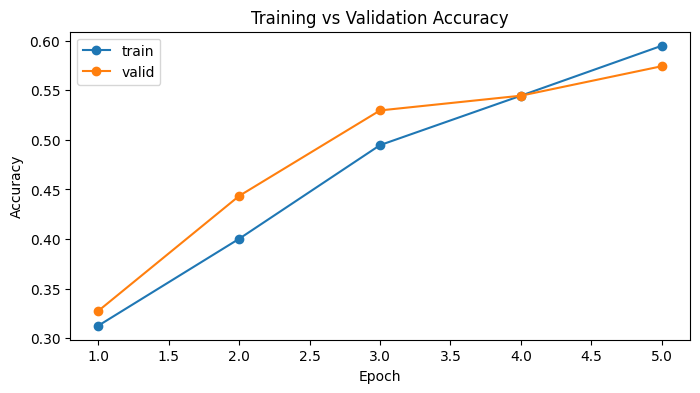

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train")
plt.plot(history_df["epoch"], history_df["valid_acc"], marker="o", label="valid")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Final Test Evaluation

In [35]:
test_loss, test_acc, y_true, y_pred = evaluate(classifier_model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=target_names))

Test loss: 1.0961
Test accuracy: 0.5389
                    precision    recall  f1-score   support

     comp.graphics       0.62      0.70      0.66       389
rec.sport.baseball       0.74      0.55      0.63       397
           sci.med       0.41      0.64      0.50       396
talk.politics.misc       0.45      0.19      0.26       310

          accuracy                           0.54      1492
         macro avg       0.55      0.52      0.51      1492
      weighted avg       0.56      0.54      0.53      1492



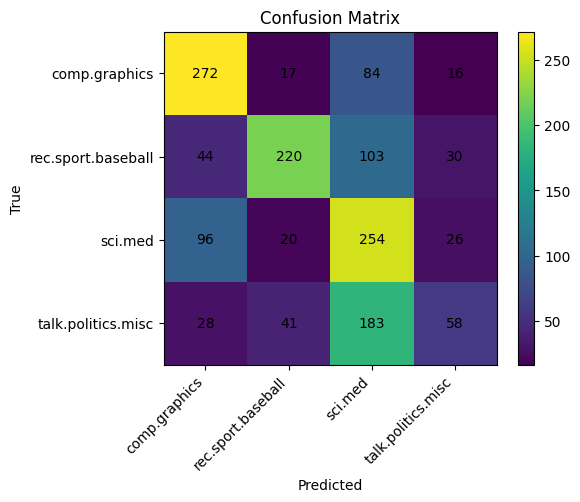

In [36]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), target_names, rotation=45, ha="right")
plt.yticks(range(num_classes), target_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Inference Function

In [37]:
@torch.no_grad()
def predict_text(model, text: str, vocab: Dict[str, int], target_names: List[str], device=DEVICE):
    model.eval()
    ids = torch.tensor([encode_text(text, vocab, max_len=MAX_LEN)], dtype=torch.long).to(device)
    logits = model(ids)
    probs = F.softmax(logits, dim=-1).squeeze(0).detach().cpu().numpy()
    pred_id = int(probs.argmax())
    return {
        "prediction": target_names[pred_id],
        "confidence": float(probs[pred_id]),
        "probabilities": {target_names[i]: float(probs[i]) for i in range(len(target_names))},
    }

sample_inputs = [
    "The baseball team won the game after a strong pitching performance.",
    "The doctor discussed treatment options for the patient and reviewed the medical study.",
    "The rendering pipeline uses pixels, color buffers, and animation frames.",
    "The government debated election law and public policy in parliament.",
]

for text in sample_inputs:
    print("TEXT:", text)
    print(predict_text(classifier_model, text, vocab, target_names))
    print("-" * 80)

TEXT: The baseball team won the game after a strong pitching performance.
{'prediction': 'rec.sport.baseball', 'confidence': 0.9965479969978333, 'probabilities': {'comp.graphics': 0.00043541722698137164, 'rec.sport.baseball': 0.9965479969978333, 'sci.med': 0.00035319876042194664, 'talk.politics.misc': 0.002663399325683713}}
--------------------------------------------------------------------------------
TEXT: The doctor discussed treatment options for the patient and reviewed the medical study.
{'prediction': 'talk.politics.misc', 'confidence': 0.37192603945732117, 'probabilities': {'comp.graphics': 0.07821698486804962, 'rec.sport.baseball': 0.3094119131565094, 'sci.med': 0.240445077419281, 'talk.politics.misc': 0.37192603945732117}}
--------------------------------------------------------------------------------
TEXT: The rendering pipeline uses pixels, color buffers, and animation frames.
{'prediction': 'comp.graphics', 'confidence': 0.7712823748588562, 'probabilities': {'comp.graphi

## Attention Inspection

Attention maps can be visualized to inspect which tokens attend to which tokens. This is useful for learning, but attention maps should not be treated as perfect explanations.

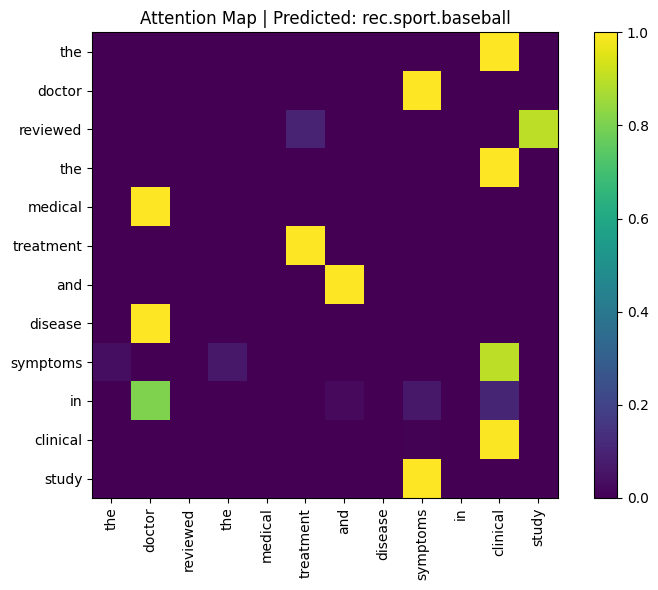

In [38]:
@torch.no_grad()
def get_attention_for_text(model, text: str, vocab: Dict[str, int], device=DEVICE, max_tokens: int = 40):
    model.eval()
    tokens = tokenize(text)[:max_tokens]
    ids = [vocab.get(token, UNK_ID) for token in tokens]
    if len(ids) == 0:
        tokens = [UNK_TOKEN]
        ids = [UNK_ID]
    ids_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    logits, attention_maps = model(ids_tensor, return_attention=True)
    pred = logits.argmax(dim=-1).item()
    # first layer, first head
    attn = attention_maps[0][0, 0, : len(tokens), : len(tokens)].detach().cpu().numpy()
    return tokens, attn, pred

example_text = "The doctor reviewed the medical treatment and disease symptoms in a clinical study."
tokens, attn, pred = get_attention_for_text(classifier_model, example_text, vocab)

plt.figure(figsize=(8, 6))
plt.imshow(attn)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Attention Map | Predicted: {target_names[pred]}")
plt.colorbar()
plt.tight_layout()
plt.show()

# Part F — Optional Baseline: Classical scikit-learn Model

A strong ML workflow compares deep learning models against simpler baselines. For text classification, TF-IDF plus logistic regression is a useful baseline.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000)),
])

baseline.fit(X_train, y_train_split)
baseline_pred = baseline.predict(X_test_raw)
print("Baseline accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred, target_names=target_names))

Baseline accuracy: 0.8438337801608579
                    precision    recall  f1-score   support

     comp.graphics       0.85      0.90      0.87       389
rec.sport.baseball       0.82      0.89      0.85       397
           sci.med       0.86      0.79      0.82       396
talk.politics.misc       0.86      0.79      0.82       310

          accuracy                           0.84      1492
         macro avg       0.85      0.84      0.84      1492
      weighted avg       0.84      0.84      0.84      1492



## Project Discussion

Our custom Transformer encoder learns document representations by letting every token attend to every other token. For document classification, we pool encoded token vectors and use a classification head.

### What worked

- Self-attention can model relationships across a whole document segment.
- The same core encoder idea can be adapted for classification.
- Custom implementation helps us understand every component.

### What can be improved

- Use a subword tokenizer instead of regex word tokenization.
- Use pretrained embeddings or pretrained Transformer models.
- Train longer and tune hyperparameters.
- Use a larger vocabulary and longer sequences.
- Add a `[CLS]` token and pool from it, like BERT.
- Use pre-norm blocks for deeper stability.
- Use learning-rate warmup.
- Use efficient attention for longer documents.

# Part G — Interview Notes

## Interview Questions and Strong Answer Points

### 1. What problem did the Transformer solve?

The Transformer solved the sequential computation bottleneck of RNN-based sequence models by replacing recurrence with self-attention. This allowed better parallelization and shorter information paths between distant tokens.

### 2. What is self-attention?

Self-attention allows each token in a sequence to compute a weighted mixture of all tokens in the same sequence. The weights are based on query-key similarity, and the output is a weighted sum of values.

### 3. Why do we need Q, K, and V?

Queries represent what a token searches for, keys represent what tokens contain for matching, and values contain the information returned after the matching weights are computed.

### 4. Why scale by $\sqrt{d_k}$?

Scaling prevents dot products from becoming too large when dimensionality increases. This avoids softmax saturation and improves gradient flow.

### 5. Why is multi-head attention better than single-head attention?

Multiple heads learn different attention patterns in different representation subspaces. This gives the model richer relational understanding.

### 6. Why does the Transformer need positional encoding?

Self-attention alone is permutation-insensitive. Positional encoding adds order information so the model can distinguish token positions.

### 7. What is the difference between encoder self-attention and decoder self-attention?

Encoder self-attention can attend to all source tokens. Decoder self-attention is causally masked, so each target token can attend only to previous target tokens.

### 8. What is cross-attention?

Cross-attention happens in the decoder. Queries come from decoder states, while keys and values come from encoder outputs. This lets the decoder focus on relevant source tokens while generating target tokens.

### 9. What is the role of feed-forward layers?

Attention mixes information across positions. Feed-forward layers apply non-linear transformations to each position independently, increasing model capacity.

### 10. What is label smoothing?

Label smoothing prevents overconfident predictions by assigning a small probability mass to non-target classes. It often improves generalization.

### 11. What is the main limitation of vanilla self-attention?

The main limitation is quadratic memory and computation cost with sequence length.

### 12. Encoder-only vs decoder-only vs encoder-decoder?

- Encoder-only: best for understanding tasks such as classification and tagging.
- Decoder-only: best for auto-regressive generation.
- Encoder-decoder: best for conditional generation such as translation and summarization.

### 13. Why did Transformers become the base of modern LLMs?

Transformers parallelize well, scale effectively with data and compute, model long-range dependencies better than RNNs, and support pretraining objectives that transfer across tasks.

# Part H — Paper-to-Code Mapping

| Paper component | Code component in this notebook |
|---|---|
| Token embeddings | `nn.Embedding` in encoder/decoder |
| Positional encoding | `PositionalEncoding` |
| Scaled dot-product attention | `scaled_dot_product_attention` |
| Multi-head attention | `MultiHeadAttentionCustom` |
| Encoder layer | `TransformerEncoderBlockCustom` |
| Decoder layer | `TransformerDecoderBlockCustom` |
| Encoder stack | `TransformerEncoderCustom` |
| Decoder stack | `TransformerDecoderCustom` |
| Full Transformer | `TransformerSeq2SeqCustom` |
| Padding mask | `make_pad_mask` |
| Causal mask | `make_causal_mask`, `make_tgt_mask` |
| Label smoothing | `LabelSmoothingLoss` |
| Learning-rate schedule | `NoamScheduler` |
| Practical project | `TransformerTextClassifierCustom` |